# Real part of the Franz Keldysh effect

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from imodulator.utils import n_InGaAsP

%matplotlib inline

Failed to import lumapi: [Errno 2] No such file or directory: 'C:/Program Files/Lumerical/v232/api/python/lumapi.py'


In [7]:
Q13=n_InGaAsP(1e12, 300, 0.615, 1550, bandgap_model='jain')
Eg = Q13.get_bandgap()
lam = (Eg/Q13.hbar / (2*np.pi * Q13.c))**-1

print(f'Bandgap: {Eg.to("eV").magnitude:.3f} eV, Wavelength: {lam.to("nm").magnitude:.3f} nm')

Bandgap: 0.952 eV, Wavelength: 1303.080 nm


1.7346518087339359e-18 electron_volt ** 2 * meter ** 2 / volt ** 2
3.1340347804856822e-18 electron_volt ** 2 * meter ** 2 / volt ** 2


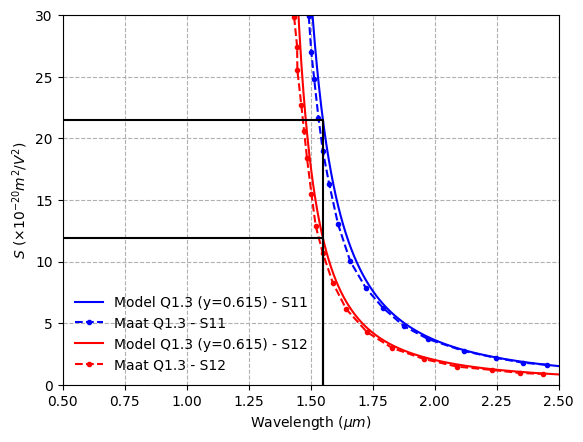

In [9]:
Q13=n_InGaAsP(1e12, 300, 0.615, 1550, bandgap_model='jain')

E=Q13.hbar * 2*np.pi / (1550*Q13.reg.nanometer) * Q13.c
Eg=Q13.get_bandgap()
n=np.sqrt(Q13.eps_s)

S11 = 21.5e-20 * Q13.reg.meter**2 / Q13.reg.volt**2
S12 = 11.9e-20 * Q13.reg.meter**2 / Q13.reg.volt**2

C_TE=S12/(E**2 / (n**4 * (Eg**2 - E**2)**2))
C_TE=C_TE.to(Q13.reg.eV**2 * Q13.reg.meter**2 / Q13.reg.volt**2)

C_TM=S11/(E**2 / (n**4 * (Eg**2 - E**2)**2))
C_TM=C_TM.to(Q13.reg.eV**2 * Q13.reg.meter**2 / Q13.reg.volt**2)

print(C_TE)
print(C_TM)

#Generate the plots
data_TE=np.loadtxt(r'Maat_Kerr_plots\Q13.csv',
                   skiprows=1, delimiter=',')[:,-2:]
data_TM=np.loadtxt(r'Maat_Kerr_plots\Q13_TM.csv',
                   skiprows=1, delimiter=',')[:,-2:]

wv=np.linspace(0.55,2.5,1000) * Q13.reg.micrometer
E=Q13.hbar * 2*np.pi / wv * Q13.c
Eg=Q13.get_bandgap()
n=np.sqrt(Q13.get_eps_s(wl=wv))

S12=C_TE*(E**2 / (n**4 * (Eg**2 - E**2)**2))
S12=S12.to(Q13.reg.meter**2 / Q13.reg.volt**2)

S11=C_TM*(E**2 / (n**4 * (Eg**2 - E**2)**2))
S11=S11.to(Q13.reg.meter**2 / Q13.reg.volt**2)

plt.figure()
plt.plot(wv, S11/1e-20, color='blue', label='Model Q1.3 (y=0.615) - S11')
plt.plot(data_TM[:,0], data_TM[:,1], color='blue', linestyle='dashed', 
         marker='o', markersize=3, label='Maat Q1.3 - S11')

plt.plot(wv, S12/1e-20, color='red', label='Model Q1.3 (y=0.615) - S12')
plt.plot(data_TE[:,0], data_TE[:,1], color='red', linestyle='dashed', 
         marker='o', markersize=3,label='Maat Q1.3 - S12')

plt.legend(frameon=False)

plt.ylim(0,30)
plt.xlim(0.5,2.5)
plt.xlabel(r'Wavelength $(\mu m)$')
plt.ylabel(r'$S$ $(\times 10^{-20} m^2/V^2)$')

plt.grid(linestyle='dashed')

# plt.plot([1.55,1.55,0.5], [0, 18.3,18.3], color='black', linestyle='dashed')
plt.plot([1.55,1.55,0.5], [0, 21.5,21.5], color='black', linestyle='solid')

# plt.plot([1.55,1.55,0.5], [0, 10.5,10.5], color='black', linestyle='dashed')
plt.plot([1.55,1.55,0.5], [0, 11.9,11.9], color='black', linestyle='solid')